### Valuation of Financial Derivatives Using Monte Carlo through Risk Neutral Pricing

This can only be done by simulating risk neutral asset paths

Ct/Bt = EQ[CT/BT | Ft]

Ct= option price, Bt=value of rf asset, Ft=available info

Risk-neutral expectation pricing formula is continuous.

To simulate a large number of sample paths take average and discount it back to present

Suitable for lookbacks, asian and barrier options

In [1]:
# Dependencies
!pip install --upgrade pandas_datareader
import math
import numpy as np
import pandas as pd
import datetime
import scipy.stats as stats
import matplotlib.pyplot as plt
from pandas_datareader import data as pdr

In [ ]:
# Keep in mind: due to the fact we are taking an average of randomly generated samples, and so therefore the calculation is itself random.
# A measure of this error is the standard error (standard deviation of expected value/ n_sample_paths)

In [ ]:
# this is a Geometric brownian motion that requires you to descretize the stochastic differential equation by breaking infinitesimals into tiny pieces. Results in delta

In [14]:
# initial derivative parameters
S = 101.15          #stock price
K = 98.01           #strike price
vol = 0.0991        #volatility (%)
r = 0.01            #risk-free rate (%)
N = 10              #number of time steps
M = 1000            #number of simulations

market_value = 3.86 #market price of option/ last price
T = ((datetime.date(2024,7,17)-datetime.date.today()).days+1)/365    #time in years, extra day cuz you can execute on day of exp. [date of exp- today]
print(T)

0.00821917808219178


In [12]:
#
dt = T/N                                  # timestep
nu_dt = (r - 0.5*vol**2)*dt               # drift term - timestep
volsdt = vol*np.sqrt(dt)                  # volatility
lnS = np.log(S)                           # log price

# Standard Error Placeholders
sum_CT = 0
sum_CT_square = 0

# Monte Carlo Method
for i in range(M):
    lnSt = lnS
    for j in range(N):
        lnSt = lnSt + nu_dt + volsdt*np.random.normal()         #get next log_st

    ST = np.exp(lnSt)   #bring it back with exp
    CT = max(0, ST - K)  #maturity is stock - strike
    sum_CT = sum_CT + CT  #
    sum_CT_square = sum_CT_square + CT*CT

# Compute Expectation and SE
C0 = np.exp(-r*T)*sum_CT/M    #discount by sum/M
sigma = np.sqrt( (sum_CT_square - sum_CT*sum_CT/M)*np.exp(-2*r*T) / (M-1) )   #std and montec method combo
SE = sigma/np.sqrt(M)   #normalize by M^2

print("Call value is ${0} with SE +/- {1}".format(np.round(C0,2),np.round(SE,2)))

Call value is $3.17 with SE +/- 0.03


Call value is $3.14 with SE +/- 0.03


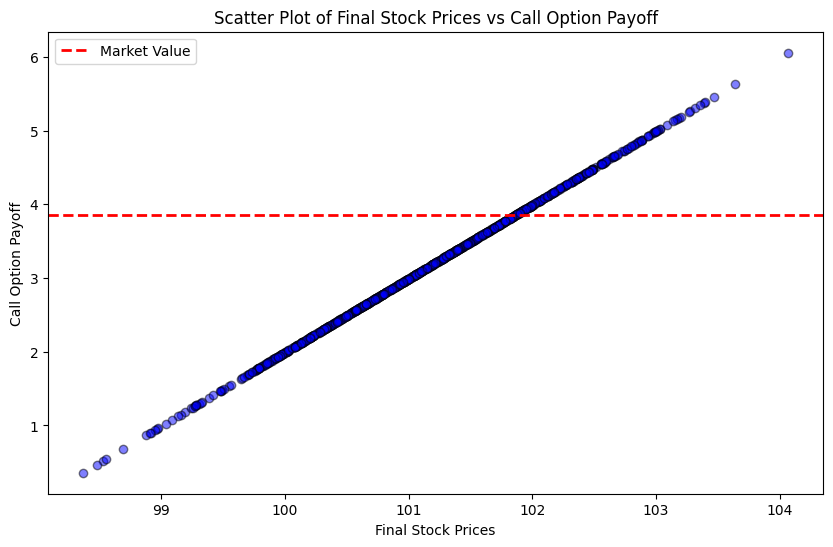

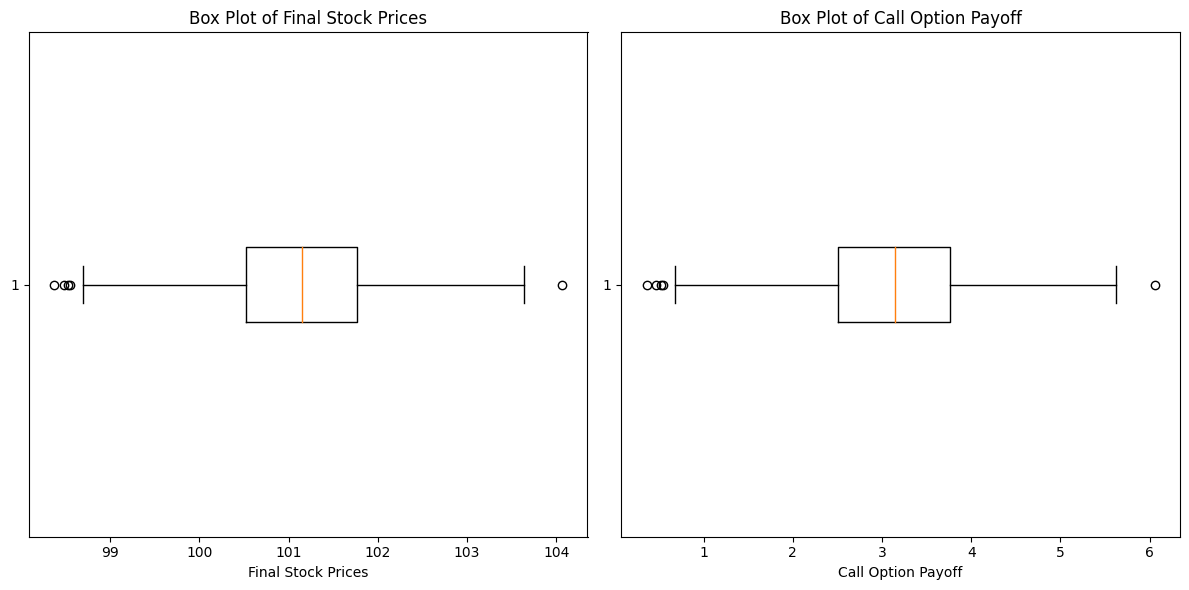

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import datetime

# Given parameters
S = 101.15          # stock price
K = 98.01           # strike price
vol = 0.0991        # volatility (%)
r = 0.01            # risk-free rate (%)
N = 10              # number of time steps
M = 1000            # number of simulations

market_value = 3.86 # market price of option/last price
T = ((datetime.date(2024, 7, 17) - datetime.date.today()).days + 1) / 365  # time in years

dt = T / N                                  # timestep
nu_dt = (r - 0.5 * vol**2) * dt             # drift term - timestep
volsdt = vol * np.sqrt(dt)                  # volatility
lnS = np.log(S)                             # log price

# Placeholders for final stock prices and payoffs
final_prices = []
payoffs = []

# Standard Error Placeholders
sum_CT = 0
sum_CT_square = 0

# Monte Carlo Method
for i in range(M):
    lnSt = lnS
    for j in range(N):
        lnSt = lnSt + nu_dt + volsdt * np.random.normal()
        if np.isnan(lnSt):
            print(f"NaN detected in simulation {i}, timestep {j}")
            break

    if np.isnan(lnSt):
        continue

    ST = np.exp(lnSt)
    if np.isnan(ST):
        print(f"NaN detected in final price for simulation {i}")
        continue

    CT = max(0, ST - K)  # maturity is stock - strike
    sum_CT += CT
    sum_CT_square += CT * CT
    final_prices.append(ST)
    payoffs.append(CT)

# Remove NaN values
final_prices = np.array(final_prices)
payoffs = np.array(payoffs)
valid_indices = ~np.isnan(final_prices) & ~np.isnan(payoffs)
final_prices = final_prices[valid_indices]
payoffs = payoffs[valid_indices]

if len(final_prices) == 0:
    raise ValueError("All simulations resulted in NaN values.")

# Compute Expectation and SE
C0 = np.exp(-r * T) * sum_CT / len(final_prices)  # discount by sum / number of valid simulations
sigma = np.sqrt((sum_CT_square - sum_CT * sum_CT / len(final_prices)) * np.exp(-2 * r * T) / (len(final_prices) - 1))  # std and Monte Carlo method combo
SE = sigma / np.sqrt(len(final_prices))   # normalize by number of valid simulations

print("Call value is ${0} with SE +/- {1}".format(np.round(C0, 2), np.round(SE, 2)))

# Create scatter plot of final prices vs payoffs
plt.figure(figsize=(10, 6))
plt.scatter(final_prices, payoffs, alpha=0.5, color='blue', edgecolors='black')
plt.axhline(y=market_value, color='red', linestyle='--', linewidth=2, label='Market Value')
plt.xlabel('Final Stock Prices')
plt.ylabel('Call Option Payoff')
plt.title('Scatter Plot of Final Stock Prices vs Call Option Payoff')
plt.legend()
plt.show()

# Create box plots of final prices and payoffs
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

ax[0].boxplot(final_prices, vert=False)
ax[0].set_title('Box Plot of Final Stock Prices')
ax[0].set_xlabel('Final Stock Prices')

ax[1].boxplot(payoffs, vert=False)
ax[1].set_title('Box Plot of Call Option Payoff')
ax[1].set_xlabel('Call Option Payoff')

plt.tight_layout()
plt.show()
